In [1]:
import numpy as np
import matplotlib.pyplot as plt

Based on https://medium.com/thedeephub/positional-encoding-explained-a-deep-dive-into-transformer-pe-65cfe8cfe10b

In [2]:
def sinusoidal_positional_encoding(max_position, d_model):
    position = np.arange(max_position)[:, np.newaxis]
    # The original formula pos / 10000^(2i/d_model) is equivalent to pos * (1 / 10000^(2i/d_model)).
    # I use the below version for numerical stability
    div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))
    
    pe = np.zeros((max_position, d_model))
    pe[:, 0::2] = np.sin(position * div_term)
    pe[:, 1::2] = np.cos(position * div_term)
    
    return pe

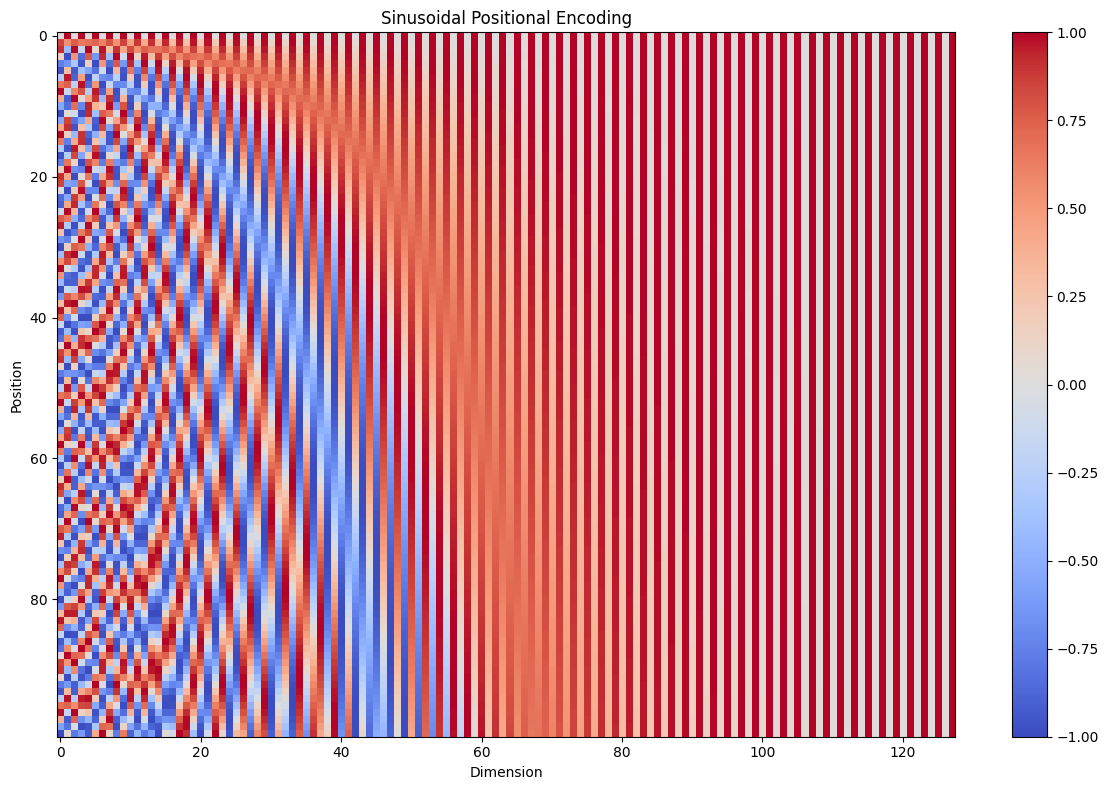

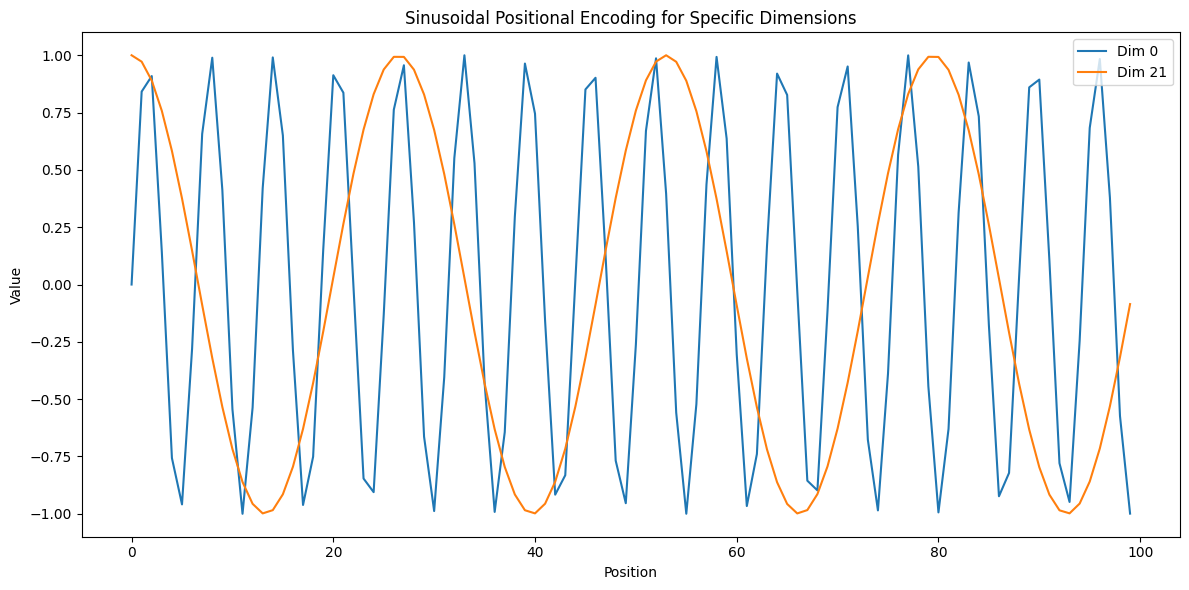

In [3]:
max_position = 100  # Maximum sequence length
d_model = 128        # Embedding dimension

pe = sinusoidal_positional_encoding(max_position, d_model)

plt.figure(figsize=(12, 8))
plt.imshow(pe, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
plt.colorbar()
plt.title('Sinusoidal Positional Encoding')
plt.xlabel('Dimension')
plt.ylabel('Position')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
dimensions = [0, 21]
for d in dimensions:
    plt.plot(pe[:, d], label=f'Dim {d}')
plt.legend()
plt.title('Sinusoidal Positional Encoding for Specific Dimensions')
plt.xlabel('Position')
plt.ylabel('Value')
plt.tight_layout()

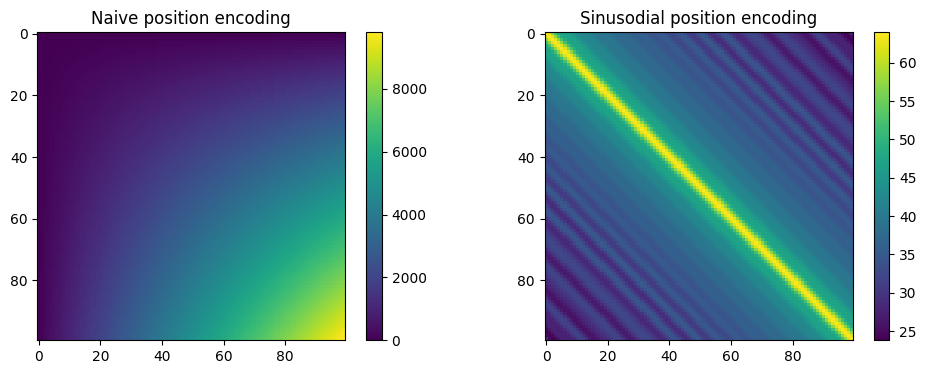

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(12)
fig.set_figheight(4)

pe_naive = np.arange(max_position)
dp_mat_naive = pe_naive[:,np.newaxis] @ pe_naive[np.newaxis,:]
im = ax1.imshow(dp_mat_naive);
ax1.set_title('Naive position encoding')
fig.colorbar(im, ax=ax1);

dp_mat = pe @ pe.T
im = ax2.imshow(dp_mat)
ax2.set_title('Sinusodial position encoding')
fig.colorbar(im, ax=ax2);